# R-CNN Data Preparation Notebook

This notebook is **only** for preparing data for an R-CNN / Faster R-CNN pipeline.

It does **not** include YOLO EDA, YOLO training, or YOLO-specific workflow steps.

## What this notebook does
1. Installs required packages
2. Downloads the bone fracture dataset
3. Copies the dataset into a separate working directory
4. Cleans and rebalances the training split
5. Converts bounding boxes into COCO-style annotations
6. Saves:
   - image folders for `train`, `valid`, and `test`
   - `instances_train.json`
   - `instances_valid.json`
   - `instances_test.json`
7. Includes an optional PyTorch dataset class for Faster R-CNN

Note: ChatGPT was used to generate the code for the following file

In [ ]:
!pip install -q kagglehub opencv-python torch torchvision

## Imports and configuration
Set the output folder and preprocessing options here.

In [ ]:
import os
import json
import math
import glob
import copy
import random
import shutil
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import kagglehub

In [ ]:
@dataclass
class PrepConfig:
    dataset_handle: str = "pkdarabi/bone-fracture-detection-computer-vision-project"
    output_root: str = "/content/bone_fracture_rcnn_ready"
    overwrite_output: bool = True

    # class cleanup / rebalance settings
    merge_class_name: str = "humerus"
    merge_into_class_name: str = "humerus fracture"
    delete_class_name: str = "fingers positive"
    delete_count: int = 150
    augment_class_name: str = "wrist positive"
    augment_count: int = 75
    seed: int = 42

cfg = PrepConfig()
random.seed(cfg.seed)
np.random.seed(cfg.seed)
cfg

PrepConfig(dataset_handle='pkdarabi/bone-fracture-detection-computer-vision-project', output_root='/content/bone_fracture_rcnn_ready', overwrite_output=True, merge_class_name='humerus', merge_into_class_name='humerus fracture', delete_class_name='fingers positive', delete_count=150, augment_class_name='wrist positive', augment_count=75, seed=42)

## Class names
These are the fracture classes used in the dataset preparation pipeline.
Update this list only if your downloaded dataset uses different class ordering.

In [ ]:
CLASS_NAMES = [
    "elbow positive",
    "fingers positive",
    "forearm fracture",
    "humerus",
    "humerus fracture",
    "shoulder fracture",
    "wrist positive",
]

CLASS_TO_ID = {name: i for i, name in enumerate(CLASS_NAMES)}
CLASS_TO_ID

{'elbow positive': 0,
 'fingers positive': 1,
 'forearm fracture': 2,
 'humerus': 3,
 'humerus fracture': 4,
 'shoulder fracture': 5,
 'wrist positive': 6}

## Helper functions
These functions handle path detection, label reading/writing, image augmentation, and COCO conversion.

In [ ]:
def find_dataset_root(download_root: str) -> str:
    candidates = []

    for root, dirs, files in os.walk(download_root):
        dirset = set(dirs)
        if {"train", "valid", "test"}.issubset(dirset):
            candidates.append(root)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find dataset root containing train/valid/test inside: {download_root}"
        )

    candidates = sorted(candidates, key=lambda p: len(Path(p).parts))
    return candidates[0]


def ensure_clean_dir(path: str, overwrite: bool = False):
    if os.path.exists(path):
        if overwrite:
            shutil.rmtree(path)
        else:
            raise FileExistsError(f"Path already exists: {path}")
    os.makedirs(path, exist_ok=True)


def copy_dataset_tree(src_root: str, dst_root: str):
    shutil.copytree(src_root, dst_root)


def split_dirs(root: str, split: str):
    split_root = os.path.join(root, split)
    images_dir = os.path.join(split_root, "images")
    labels_dir = os.path.join(split_root, "labels")
    return split_root, images_dir, labels_dir


def list_image_files(images_dir: str):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
    files = []
    for ext in exts:
        files.extend(glob.glob(os.path.join(images_dir, ext)))
    return sorted(files)


def image_to_label_path(image_path: str, labels_dir: str):
    stem = Path(image_path).stem
    return os.path.join(labels_dir, stem + ".txt")


def read_yolo_label_file(label_path: str):
    records = []
    if not os.path.exists(label_path):
        return records

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            records.append([cls, xc, yc, w, h])
    return records


def write_yolo_label_file(label_path: str, records):
    with open(label_path, "w") as f:
        for cls, xc, yc, w, h in records:
            f.write(f"{int(cls)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")


def yolo_to_coco_bbox(xc, yc, w, h, img_w, img_h):
    x = (xc - w / 2.0) * img_w
    y = (yc - h / 2.0) * img_h
    bw = w * img_w
    bh = h * img_h

    x = max(0.0, min(x, img_w - 1.0))
    y = max(0.0, min(y, img_h - 1.0))
    bw = max(1.0, min(bw, img_w - x))
    bh = max(1.0, min(bh, img_h - y))

    return [float(x), float(y), float(bw), float(bh)]


def remap_and_merge_classes(root: str, class_names):
    old_map = {name: i for i, name in enumerate(class_names)}
    merge_name = cfg.merge_class_name
    merge_into = cfg.merge_into_class_name

    if merge_name not in old_map or merge_into not in old_map:
        raise ValueError("Merge class names not found in class list.")

    merge_id = old_map[merge_name]
    target_id = old_map[merge_into]

    new_class_names = [c for c in class_names if c != merge_name]

    def reindex_class(old_cls):
        if old_cls == merge_id:
            old_cls = target_id
        if old_cls > merge_id:
            return old_cls - 1
        elif old_cls < merge_id:
            return old_cls
        else:
            return target_id if target_id < merge_id else target_id - 1

    for split in ["train", "valid", "test"]:
        _, _, labels_dir = split_dirs(root, split)
        for label_file in sorted(glob.glob(os.path.join(labels_dir, "*.txt"))):
            records = read_yolo_label_file(label_file)
            if not records:
                continue
            new_records = []
            for cls, xc, yc, w, h in records:
                new_cls = reindex_class(cls)
                new_records.append([new_cls, xc, yc, w, h])
            write_yolo_label_file(label_file, new_records)

    return new_class_names


def delete_samples_for_class(root: str, class_names, split="train"):
    target_name = cfg.delete_class_name
    target_id = class_names.index(target_name)

    _, images_dir, labels_dir = split_dirs(root, split)
    candidates = []

    for image_path in list_image_files(images_dir):
        label_path = image_to_label_path(image_path, labels_dir)
        records = read_yolo_label_file(label_path)
        if any(r[0] == target_id for r in records):
            candidates.append((image_path, label_path))

    random.shuffle(candidates)
    to_delete = candidates[: min(cfg.delete_count, len(candidates))]

    for image_path, label_path in to_delete:
        if os.path.exists(image_path):
            os.remove(image_path)
        if os.path.exists(label_path):
            os.remove(label_path)

    return len(to_delete)


def augment_image_and_boxes(image, records):
    aug_type = random.choice(["flip", "brightness", "rotate"])

    if aug_type == "flip":
        aug_img = cv2.flip(image, 1)
        aug_records = []
        for cls, xc, yc, w, h in records:
            aug_records.append([cls, 1.0 - xc, yc, w, h])
        return aug_img, aug_records

    if aug_type == "brightness":
        alpha = random.uniform(0.9, 1.1)
        beta = random.randint(-15, 15)
        aug_img = cv2.convertScaleAbs(image, alpha=alpha, beta=beta)
        return aug_img, copy.deepcopy(records)

    # small rotation
    h_img, w_img = image.shape[:2]
    angle = random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((w_img / 2, h_img / 2), angle, 1.0)
    aug_img = cv2.warpAffine(
        image,
        M,
        (w_img, h_img),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101,
    )
    return aug_img, copy.deepcopy(records)


def augment_samples_for_class(root: str, class_names, split="train"):
    target_name = cfg.augment_class_name
    target_id = class_names.index(target_name)

    _, images_dir, labels_dir = split_dirs(root, split)
    candidates = []

    for image_path in list_image_files(images_dir):
        label_path = image_to_label_path(image_path, labels_dir)
        records = read_yolo_label_file(label_path)
        if any(r[0] == target_id for r in records):
            candidates.append((image_path, label_path, records))

    if not candidates:
        return 0

    created = 0
    idx = 0
    while created < cfg.augment_count:
        image_path, label_path, records = candidates[idx % len(candidates)]
        image = cv2.imread(image_path)
        if image is None:
            idx += 1
            continue

        aug_img, aug_records = augment_image_and_boxes(image, records)

        stem = Path(image_path).stem
        suffix = Path(image_path).suffix
        new_stem = f"{stem}_aug_{created:03d}"

        new_image_path = os.path.join(images_dir, new_stem + suffix)
        new_label_path = os.path.join(labels_dir, new_stem + ".txt")

        cv2.imwrite(new_image_path, aug_img)
        write_yolo_label_file(new_label_path, aug_records)

        created += 1
        idx += 1

    return created


def make_coco_annotations(root: str, split: str, class_names):
    _, images_dir, labels_dir = split_dirs(root, split)

    images = []
    annotations = []
    categories = [{"id": i + 1, "name": name} for i, name in enumerate(class_names)]

    ann_id = 1
    image_id = 1

    for image_path in list_image_files(images_dir):
        file_name = os.path.basename(image_path)
        img = cv2.imread(image_path)
        if img is None:
            continue

        h_img, w_img = img.shape[:2]
        images.append(
            {
                "id": image_id,
                "file_name": file_name,
                "width": w_img,
                "height": h_img,
            }
        )

        label_path = image_to_label_path(image_path, labels_dir)
        records = read_yolo_label_file(label_path)

        for cls, xc, yc, w, h in records:
            bbox = yolo_to_coco_bbox(xc, yc, w, h, w_img, h_img)
            area = bbox[2] * bbox[3]
            annotations.append(
                {
                    "id": ann_id,
                    "image_id": image_id,
                    "category_id": int(cls) + 1,
                    "bbox": bbox,
                    "area": float(area),
                    "iscrowd": 0,
                }
            )
            ann_id += 1

        image_id += 1

    return {
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }


def save_json(path: str, data: dict):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

## Download dataset
This downloads the original dataset and locates the folder that contains `train`, `valid`, and `test`.

In [ ]:
download_root = kagglehub.dataset_download(cfg.dataset_handle)
dataset_root = find_dataset_root(download_root)

print("Downloaded root:", download_root)
print("Detected dataset root:", dataset_root)

Using Colab cache for faster access to the 'bone-fracture-detection-computer-vision-project' dataset.
Downloaded root: /kaggle/input/bone-fracture-detection-computer-vision-project
Detected dataset root: /kaggle/input/bone-fracture-detection-computer-vision-project/bone fracture detection.v4-v4.yolov8


## Copy dataset into a separate R-CNN working folder
This prevents edits from touching the original downloaded dataset.

In [ ]:
output_root = cfg.output_root

if os.path.exists(output_root) and cfg.overwrite_output:
    shutil.rmtree(output_root)

copy_dataset_tree(dataset_root, output_root)
print("Working dataset copied to:", output_root)

Working dataset copied to: /content/bone_fracture_rcnn_ready


## Merge and reindex classes
This removes the standalone `humerus` class by merging it into `humerus fracture`, then reindexes the class IDs.

In [ ]:
updated_class_names = remap_and_merge_classes(output_root, CLASS_NAMES)
updated_class_names

['elbow positive',
 'fingers positive',
 'forearm fracture',
 'humerus fracture',
 'shoulder fracture',
 'wrist positive']

## Delete a subset of one training class
This removes a number of training samples from the `fingers positive` class to reduce imbalance.

In [ ]:
deleted_count = delete_samples_for_class(output_root, updated_class_names, split="train")
print("Deleted training samples:", deleted_count)

Deleted training samples: 150


## Augment a subset of one training class
This creates new images and labels for the `wrist positive` class.

In [ ]:
augmented_count = augment_samples_for_class(output_root, updated_class_names, split="train")
print("Created augmented training samples:", augmented_count)

Created augmented training samples: 75


## Convert labels to COCO JSON
This is the key output needed for many R-CNN / Faster R-CNN training pipelines.

In [ ]:
annotations_dir = os.path.join(output_root, "annotations")
os.makedirs(annotations_dir, exist_ok=True)

for split in ["train", "valid", "test"]:
    coco = make_coco_annotations(output_root, split, updated_class_names)
    save_path = os.path.join(annotations_dir, f"instances_{split}.json")
    save_json(save_path, coco)
    print(f"Saved {split} annotations to:", save_path)

Saved train annotations to: /content/bone_fracture_rcnn_ready/annotations/instances_train.json
Saved valid annotations to: /content/bone_fracture_rcnn_ready/annotations/instances_valid.json
Saved test annotations to: /content/bone_fracture_rcnn_ready/annotations/instances_test.json


## Save a manifest file
This records the dataset structure and final class names.

In [ ]:
manifest = {
    "dataset_root": output_root,
    "splits": {
        "train_images": os.path.join(output_root, "train", "images"),
        "valid_images": os.path.join(output_root, "valid", "images"),
        "test_images": os.path.join(output_root, "test", "images"),
    },
    "annotations": {
        "train": os.path.join(output_root, "annotations", "instances_train.json"),
        "valid": os.path.join(output_root, "annotations", "instances_valid.json"),
        "test": os.path.join(output_root, "annotations", "instances_test.json"),
    },
    "class_names": updated_class_names,
}

manifest_path = os.path.join(output_root, "rcnn_dataset_manifest.json")
save_json(manifest_path, manifest)
print("Saved manifest to:", manifest_path)
manifest

Saved manifest to: /content/bone_fracture_rcnn_ready/rcnn_dataset_manifest.json


{'dataset_root': '/content/bone_fracture_rcnn_ready',
 'splits': {'train_images': '/content/bone_fracture_rcnn_ready/train/images',
  'valid_images': '/content/bone_fracture_rcnn_ready/valid/images',
  'test_images': '/content/bone_fracture_rcnn_ready/test/images'},
 'annotations': {'train': '/content/bone_fracture_rcnn_ready/annotations/instances_train.json',
  'valid': '/content/bone_fracture_rcnn_ready/annotations/instances_valid.json',
  'test': '/content/bone_fracture_rcnn_ready/annotations/instances_test.json'},
 'class_names': ['elbow positive',
  'fingers positive',
  'forearm fracture',
  'humerus fracture',
  'shoulder fracture',
  'wrist positive']}

## Optional: PyTorch dataset class for Faster R-CNN
This cell creates a dataset class that returns:
- image tensor
- target dictionary with boxes, labels, areas, image_id, and iscrowd

This is useful for torchvision detection models.

In [ ]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms.functional as F

class BoneFractureRCNNDataset(Dataset):
    def __init__(self, images_dir, annotation_json):
        self.images_dir = images_dir
        with open(annotation_json, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        self.ann_map = {}
        for ann in self.annotations:
            self.ann_map.setdefault(ann["image_id"], []).append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_info = self.images[idx]
        image_path = os.path.join(self.images_dir, image_info["file_name"])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        anns = self.ann_map.get(image_info["id"], [])

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x + w, y + h])
            labels.append(ann["category_id"])
            areas.append(ann["area"])
            iscrowd.append(ann.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        image_id = torch.tensor([image_info["id"]], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": areas,
            "iscrowd": iscrowd,
            "image_id": image_id,
        }

        image = F.to_tensor(image)
        return image, target

## Optional quick test
This checks whether the train split can be loaded correctly by a torchvision-style dataset.

In [ ]:
train_dataset = BoneFractureRCNNDataset(
    images_dir=manifest["splits"]["train_images"],
    annotation_json=manifest["annotations"]["train"]
)

img, target = train_dataset[0]
print("Image tensor shape:", img.shape)
print("Target keys:", target.keys())
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"])

Image tensor shape: torch.Size([3, 1024, 1024])
Target keys: dict_keys(['boxes', 'labels', 'area', 'iscrowd', 'image_id'])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])


In [ ]:
!ls /content/bone_fracture_rcnn_ready
!ls /content/bone_fracture_rcnn_ready/train/images | head

annotations  rcnn_dataset_manifest.json  test	valid
data.yaml    README.dataset.txt		 train
distal-humeral-fractures-2-_JPEG.rf.39ba3f53047ecb4064613850a1c76fc1.jpg
distal-humeral-fractures-2-_JPEG.rf.525ce876785d0fd798ec3af1593e5bc1.jpg
distal-humeral-fractures-2-_JPEG.rf.f9442db05ec473187c60870d407c9e8f.jpg
elbow-dislocation-with-coronoid-process-fracture_jpg.rf.234153519323ba2b9aa2e603b0a43771.jpg
elbow-dislocation-with-coronoid-process-fracture_jpg.rf.75b67d2e40fe637ba2838e1283f970c5.jpg
elbow-dislocation-with-coronoid-process-fracture_jpg.rf.76486fb6ffe2b6c7da0e4922e58a088f.jpg
fracture-of-the-humeral-capitellum-milch-type-1-1-1-_jpg.rf.4c16d0817782b56497b9f18bca2b0fdd.jpg
fracture-of-the-humeral-capitellum-milch-type-1-1-1-_jpg.rf.8b022b79c884d0b37d923a3c961591c6.jpg
fracture-of-the-humeral-capitellum-milch-type-1-1-1-_jpg.rf.f40a3ca2a57d511a40839bd1ca615d54.jpg
image1_0_png.rf.208b9fc171409973fd0f9af79cdcfead.jpg


## Creating the Model

In [ ]:
# Install required packages
!pip install -q torch torchvision pycocotools matplotlib pillow

In [ ]:
import os
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# Check device
print("Device Check:")
print(f"  CUDA available: {torch.cuda.is_available()}")
print(f"  MPS available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")
print("  CPU: Always available")

if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = "CUDA GPU"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    device_name = "Apple MPS"
else:
    device = torch.device("cpu")
    device_name = "CPU"

print(f"\nUsing device: {device_name} ({device})")

Device Check:
  CUDA available: True
  MPS available: False
  CPU: Always available

Using device: CUDA GPU (cuda)


In [ ]:
# Dataset paths
dataset_root = Path("/content/bone_fracture_rcnn_ready")
train_images_dir = dataset_root / "train" / "images"
valid_images_dir = dataset_root / "valid" / "images"
test_images_dir  = dataset_root / "test" / "images"

train_ann_path = dataset_root / "annotations" / "instances_train.json"
valid_ann_path = dataset_root / "annotations" / "instances_valid.json"
test_ann_path  = dataset_root / "annotations" / "instances_test.json"

# Output paths
output_dir = Path("/content/runs/faster_rcnn_bone_fracture")
output_dir.mkdir(parents=True, exist_ok=True)

best_model_path = output_dir / "best_faster_rcnn.pth"
last_model_path = output_dir / "last_faster_rcnn.pth"

# Training hyperparameters
NUM_EPOCHS = 20
BATCH_SIZE = 4 if device.type != "cpu" else 2
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2 if device.type != "cpu" else 0
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

required_paths = [
    train_images_dir, valid_images_dir, test_images_dir,
    train_ann_path, valid_ann_path, test_ann_path
]

missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(
        "These required dataset files/folders were not found:\n" + "\n".join(missing)
    )

print("Dataset root:", dataset_root)
print("Output dir:", output_dir)
print("Train annotations:", train_ann_path)
print("Valid annotations:", valid_ann_path)
print("Test annotations:", test_ann_path)

Dataset root: /content/bone_fracture_rcnn_ready
Output dir: /content/runs/faster_rcnn_bone_fracture
Train annotations: /content/bone_fracture_rcnn_ready/annotations/instances_train.json
Valid annotations: /content/bone_fracture_rcnn_ready/annotations/instances_valid.json
Test annotations: /content/bone_fracture_rcnn_ready/annotations/instances_test.json


In [ ]:
with open(train_ann_path, "r") as f:
    train_coco = json.load(f)

categories = sorted(train_coco["categories"], key=lambda x: x["id"])
category_id_to_name = {c["id"]: c["name"] for c in categories}
category_name_to_id = {c["name"]: c["id"] for c in categories}

# Faster R-CNN expects class indices from 1..N, with 0 reserved for background.
# Our prepared COCO file should already use positive category ids.
num_classes = len(categories) + 1

print("Categories:")
for c in categories:
    print(f"  {c['id']}: {c['name']}")
print(f"\nNumber of object classes: {len(categories)}")
print(f"Number of classes passed to model (including background): {num_classes}")

Categories:
  1: elbow positive
  2: fingers positive
  3: forearm fracture
  4: humerus fracture
  5: shoulder fracture
  6: wrist positive

Number of object classes: 6
Number of classes passed to model (including background): 7


In [ ]:
class BoneFractureCocoDataset(Dataset):
    def __init__(self, images_dir, annotation_path):
        self.images_dir = Path(images_dir)
        self.annotation_path = Path(annotation_path)

        with open(self.annotation_path, "r") as f:
            coco = json.load(f)

        self.images = sorted(coco["images"], key=lambda x: x["id"])
        self.categories = coco["categories"]
        self.annotations = coco["annotations"]

        self.image_id_to_info = {img["id"]: img for img in self.images}
        self.image_id_to_anns = {}
        for ann in self.annotations:
            self.image_id_to_anns.setdefault(ann["image_id"], []).append(ann)

        self.ids = [img["id"] for img in self.images]

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        image_id = self.ids[idx]
        image_info = self.image_id_to_info[image_id]
        image_path = self.images_dir / image_info["file_name"]

        image = Image.open(image_path).convert("RGB")
        anns = self.image_id_to_anns.get(image_id, [])

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            x2 = x + w
            y2 = y + h

            # skip invalid boxes
            if w <= 0 or h <= 0:
                continue
            if x2 <= x or y2 <= y:
                continue

            boxes.append([x, y, x2, y2])
            labels.append(int(ann["category_id"]))
            areas.append(float(ann.get("area", w * h)))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        if boxes.numel() == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd,
        }

        image = F.to_tensor(image)
        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
train_dataset = BoneFractureCocoDataset(train_images_dir, train_ann_path)
valid_dataset = BoneFractureCocoDataset(valid_images_dir, valid_ann_path)
test_dataset  = BoneFractureCocoDataset(test_images_dir, test_ann_path)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

print(f"Train images: {len(train_dataset)}")
print(f"Valid images: {len(valid_dataset)}")
print(f"Test images:  {len(test_dataset)}")

Train images: 3556
Valid images: 348
Test images:  169


In [ ]:
sample_img, sample_target = train_dataset[0]
print("Image tensor shape:", sample_img.shape)
print("Target keys:", sample_target.keys())
print("Boxes shape:", sample_target["boxes"].shape)
print("Labels:", sample_target["labels"][:10])

Image tensor shape: torch.Size([3, 1024, 1024])
Target keys: dict_keys(['boxes', 'labels', 'image_id', 'area', 'iscrowd'])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])


In [ ]:
def get_model(num_classes):
    weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn(weights=weights)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(num_classes)
model.to(device)
print("Model initialized: Faster R-CNN (ResNet-50 FPN)")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 188MB/s]


Model initialized: Faster R-CNN (ResNet-50 FPN)


In [ ]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(loader), 1)


@torch.no_grad()
def validate_one_epoch(model, loader, device):
    # torchvision detection models only return losses in train mode when targets are provided.
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        total_loss += loss.item()

    return total_loss / max(len(loader), 1)

In [ ]:
history = {
    "train_loss": [],
    "valid_loss": [],
}

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    valid_loss = validate_one_epoch(model, valid_loader, device)

    lr_scheduler.step()

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Valid Loss: {valid_loss:.4f}"
    )

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "categories": categories,
        },
        last_model_path,
    )

    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "categories": categories,
            },
            best_model_path,
        )
        print(f"  Saved new best model to: {best_model_path}")

print("\nTraining finished.")
print("Best validation loss:", best_val_loss)

Epoch [1/20] | Train Loss: 0.1460 | Valid Loss: 0.1481
  Saved new best model to: /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth
Epoch [2/20] | Train Loss: 0.1334 | Valid Loss: 0.1417
  Saved new best model to: /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth
Epoch [3/20] | Train Loss: 0.1279 | Valid Loss: 0.1603
Epoch [4/20] | Train Loss: 0.1224 | Valid Loss: 0.1419
Epoch [5/20] | Train Loss: 0.1161 | Valid Loss: 0.1317
  Saved new best model to: /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth
Epoch [6/20] | Train Loss: 0.0941 | Valid Loss: 0.1305
  Saved new best model to: /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth
Epoch [7/20] | Train Loss: 0.0863 | Valid Loss: 0.1340
Epoch [8/20] | Train Loss: 0.0807 | Valid Loss: 0.1362
Epoch [9/20] | Train Loss: 0.0754 | Valid Loss: 0.1464
Epoch [10/20] | Train Loss: 0.0720 | Valid Loss: 0.1560
Epoch [11/20] | Train Loss: 0.0660 | Valid Loss: 0.1616
Epoch [12/20] | Train Loss: 0.0648 | Vali

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth \
/content/drive/MyDrive/best_faster_rcnn.pth

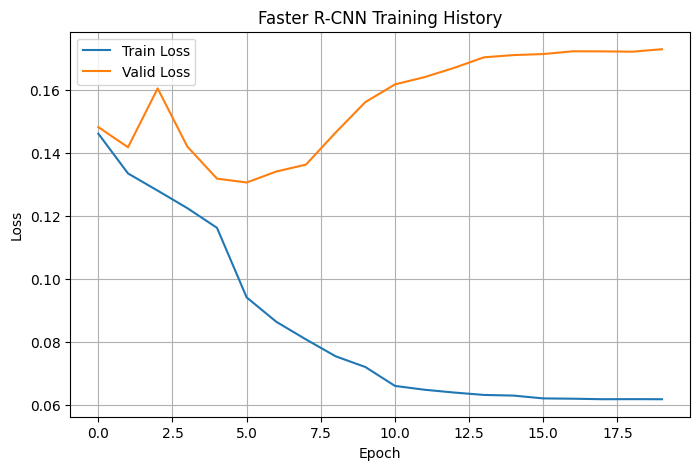

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["valid_loss"], label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Faster R-CNN Training History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)
model = get_model(num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"Loaded best model from: {best_model_path}")
print(f"Best checkpoint epoch: {checkpoint['epoch']}")
print(f"Validation loss at save: {checkpoint['valid_loss']:.4f}")

Loaded best model from: /content/runs/faster_rcnn_bone_fracture/best_faster_rcnn.pth
Best checkpoint epoch: 6
Validation loss at save: 0.1305


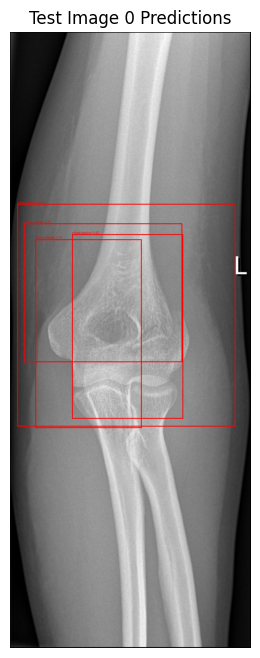

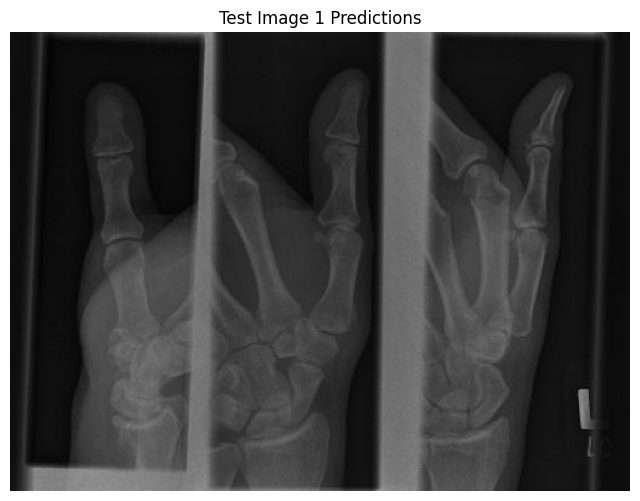

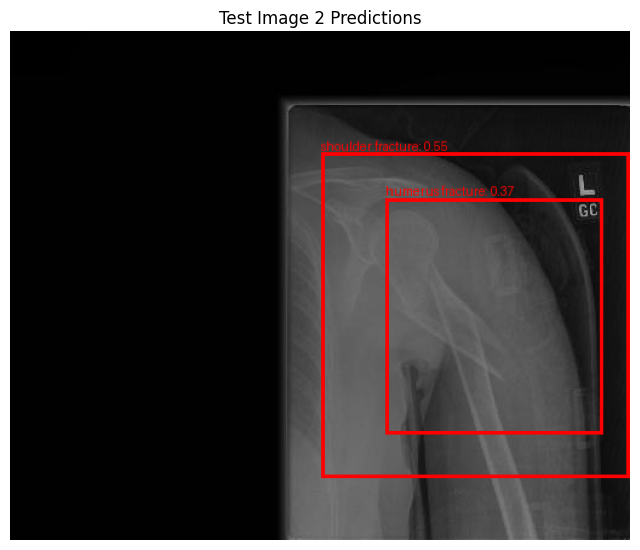

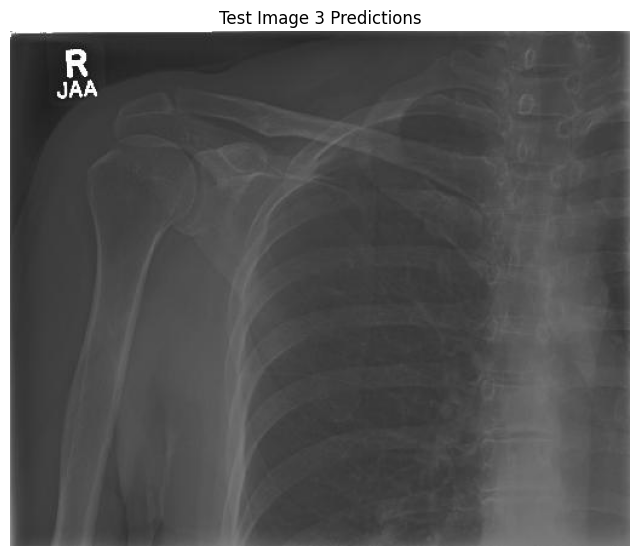

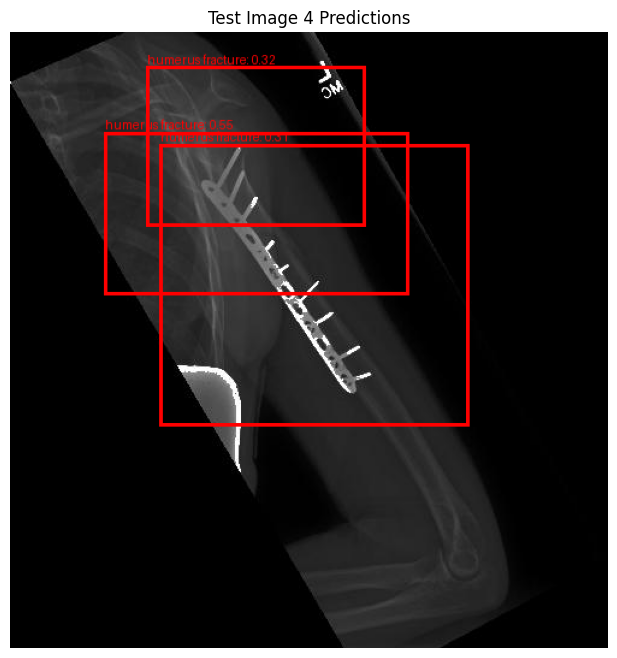

In [ ]:
def draw_predictions(image_pil, boxes, labels, scores, score_thresh=0.3):
    image_draw = image_pil.copy()
    draw = ImageDraw.Draw(image_draw)

    for box, label, score in zip(boxes, labels, scores):
        if score < score_thresh:
            continue

        x1, y1, x2, y2 = [float(v) for v in box]
        class_name = category_id_to_name.get(int(label), f"class_{int(label)}")
        text = f"{class_name}: {score:.2f}"

        draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
        draw.text((x1, max(0, y1 - 12)), text, fill="red")

    return image_draw


num_examples = min(5, len(test_dataset))
score_threshold = 0.3

for idx in range(num_examples):
    image_tensor, target = test_dataset[idx]
    image_pil = F.to_pil_image(image_tensor)

    with torch.no_grad():
        predictions = model([image_tensor.to(device)])[0]

    pred_boxes = predictions["boxes"].detach().cpu()
    pred_labels = predictions["labels"].detach().cpu()
    pred_scores = predictions["scores"].detach().cpu()

    vis = draw_predictions(
        image_pil=image_pil,
        boxes=pred_boxes,
        labels=pred_labels,
        scores=pred_scores,
        score_thresh=score_threshold,
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(vis)
    plt.title(f"Test Image {idx} Predictions")
    plt.axis("off")
    plt.show()

##Get Metrics

In [ ]:
!pip install -q pycocotools

import json
from tqdm.auto import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

GT_PATH = "/content/bone_fracture_rcnn_ready/annotations/instances_valid.json"
PRED_PATH = "/content/bone_fracture_rcnn_ready/predictions.json"

model.eval()
predictions = []

with torch.no_grad():
    for images, targets in tqdm(valid_loader, desc="Evaluating"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for target, output in zip(targets, outputs):
            image_id = int(target["image_id"].item())

            boxes = output["boxes"].cpu().numpy()
            scores = output["scores"].cpu().numpy()
            labels = output["labels"].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                xmin, ymin, xmax, ymax = box
                predictions.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [
                        float(xmin),
                        float(ymin),
                        float(xmax - xmin),
                        float(ymax - ymin),
                    ],
                    "score": float(score),
                })

with open(PRED_PATH, "w") as f:
    json.dump(predictions, f)

coco_gt = COCO(GT_PATH)
coco_dt = coco_gt.loadRes(PRED_PATH)

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

print("\nFinal Metrics")
print(f"mAP50: {coco_eval.stats[1]:.3f}")
print(f"mAP50-95: {coco_eval.stats[0]:.3f}")
print(f"Recall: {coco_eval.stats[8]:.3f}")

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.59s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.067
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.208
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.024
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.115
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.276
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [ ]:
precision = coco_eval.eval['precision'][coco_eval.eval['precision'] > -1].mean()
print(f"Precision: {precision:.3f}")

Precision: 0.050


##Get Bets Path and Metrics

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Load best model from file

In [42]:
import torch
import torchvision

BEST_MODEL_PATH = "/content/drive/MyDrive/UWaterloo/4A/MSE 446/best_faster_rcnn.pth"

num_classes = 7   # adjust if needed

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)

in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes
)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])

model.to(device)
model.eval()

print("Best model loaded.")

Best model loaded.


###Get Metrics

In [45]:
!pip install -q pycocotools

import json
import numpy as np
import torch
from tqdm.auto import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

GT_PATH = "/content/bone_fracture_rcnn_ready/annotations/instances_valid.json"
PRED_PATH = "/content/bone_fracture_rcnn_ready/predictions.json"

model.eval()
predictions = []

with torch.no_grad():
    for images, targets in tqdm(valid_loader, desc="Evaluating"):
        images = [img.to(device) for img in images]
        outputs = model(images)

        for target, output in zip(targets, outputs):
            image_id = int(target["image_id"].item())

            boxes = output["boxes"].cpu().numpy()
            scores = output["scores"].cpu().numpy()
            labels = output["labels"].cpu().numpy()

            for box, score, label in zip(boxes, scores, labels):
                xmin, ymin, xmax, ymax = box
                predictions.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [
                        float(xmin),
                        float(ymin),
                        float(xmax - xmin),
                        float(ymax - ymin),
                    ],
                    "score": float(score),
                })

with open(PRED_PATH, "w") as f:
    json.dump(predictions, f)

coco_gt = COCO(GT_PATH)
coco_dt = coco_gt.loadRes(PRED_PATH)

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

precision = coco_eval.eval["precision"]
overall_precision = precision[precision > -1].mean()

print("\nOverall Metrics")
print("-" * 35)
print(f"mAP50: {coco_eval.stats[1]:.3f}")
print(f"mAP50-95: {coco_eval.stats[0]:.3f}")
print(f"Precision: {overall_precision:.3f}")
print(f"Recall: {coco_eval.stats[8]:.3f}")

precisions = coco_eval.eval["precision"]
cat_ids = coco_gt.getCatIds()
cat_info = coco_gt.loadCats(cat_ids)

per_class_ap = {}

print("\nPer-class AP (IoU=0.50:0.95)")
print("-" * 35)

for class_idx, cat in enumerate(cat_info):
    class_name = cat["name"]
    class_precision = precisions[:, :, class_idx, 0, -1]
    class_precision = class_precision[class_precision > -1]

    ap = float(np.mean(class_precision)) if class_precision.size else float("nan")
    per_class_ap[class_name] = ap

    print(f"{class_name}: {ap:.3f}")

valid_per_class_ap = {k: v for k, v in per_class_ap.items() if not np.isnan(v)}

best_class = max(valid_per_class_ap, key=valid_per_class_ap.get)
worst_class = min(valid_per_class_ap, key=valid_per_class_ap.get)

print("\nSummary")
print("-" * 35)
print(f"Best class: {best_class} ({valid_per_class_ap[best_class]:.3f})")
print(f"Worst class: {worst_class} ({valid_per_class_ap[worst_class]:.3f})")

Evaluating:   0%|          | 0/87 [00:00<?, ?it/s]

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.21s).
Accumulating evaluation results...
DONE (t=0.07s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.211
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.024
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.070
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.117
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.275
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet